In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from tqdm import tqdm
import h5py
import pandas as pd

from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import romb
from scipy.special import erf

import astropy.units as u
from astropy.cosmology import z_at_value

from default_globals import *
from redshift_utils import *
from qlf_utils import log10_QLF_shen, log10_QLF_kulkarni, L2M, get_n_of_z, numdens2pdf, pdf2numdens
from utils import make_nice_plots, truncnorm_pdf_inplace

make_nice_plots()

COLORS = ['orangered', 'navy', 'teal', 'goldenrod', 'hotpink', 'indigo', 'crimson']


In [2]:
AGN_DIST_DIR = '/home/lucas/Documents/PhD/darksirenpop/agn_distribution'
LOG10_LBOL_THRESHES = np.array([44.5, 45.0, 45.5, 46.0, 46.5])
ZMIN = 1e-6
ZMAX = 10
REDSHIFT = np.linspace(ZMIN, ZMAX, 1024+1)

VERBOSE = True
AGN_ZMAX = 10.
Z_INTEGRAL_AX = np.linspace(ZMIN, ZMAX, int(512)+1)  # Sets the resolution of the redshift prior, should capture all information of AGN posteriors, see Gray et al. 2022, 2023
QUAIA_PATH = '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'

AGN_ZCUT = 1.5

In [3]:
# Dealing with Kulkarni QLF for z > 3.5

def remove_peak(pdf, z, zstart=3, zstop=3.5):
    '''
    Stitch an exponential decay to the PDF starting at z=3.5.
    We match the value and slope of the pdf at z=3.5.
    '''

    selec = (z > zstart) & (z < zstop)
    z_fit = z[selec]
    pdf_fit = pdf[selec]

    y0 = np.interp(zstop, z, pdf)  # Value of pdf at zstop

    def anchored_exp(x, b):
        return y0 * np.exp(b * (x - zstop))

    param, _ = curve_fit(anchored_exp, z_fit, pdf_fit, p0=[-1])

    corrected_pdf = pdf.copy()
    selec2 = (z >= zstop)
    corrected_pdf[selec2] = anchored_exp(z[selec2], *param)
    corrected_pdf /= romb(corrected_pdf, dx=np.diff(z)[0])
    return corrected_pdf, param


# Generate AGN priors

kulkarni...


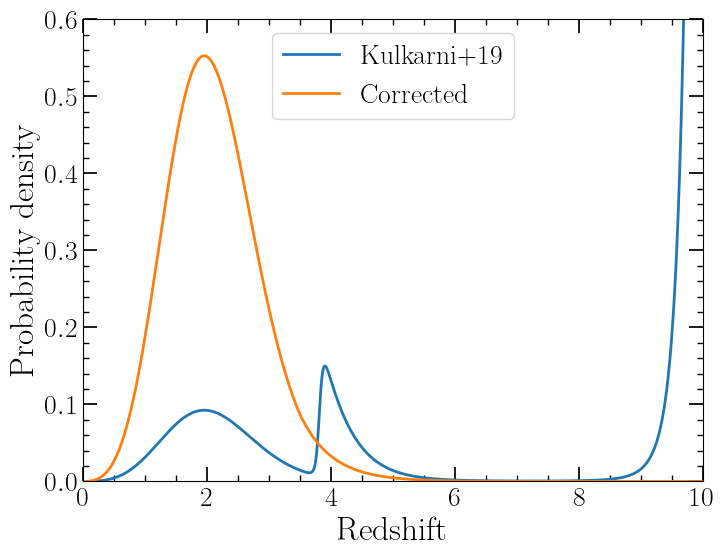

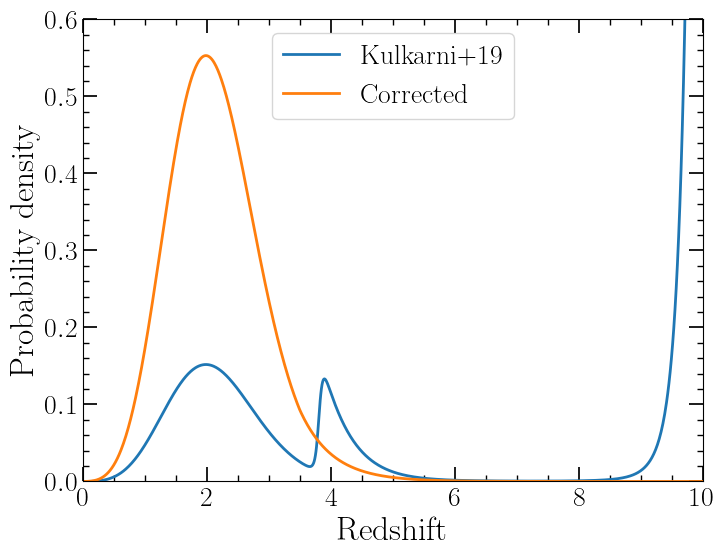

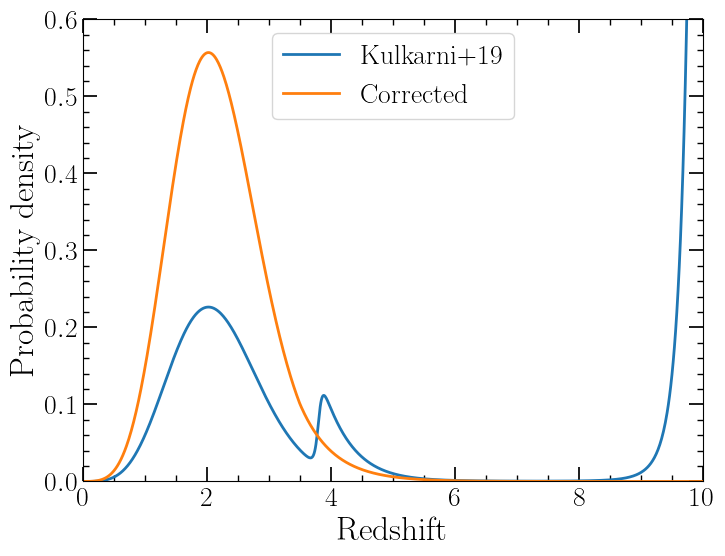

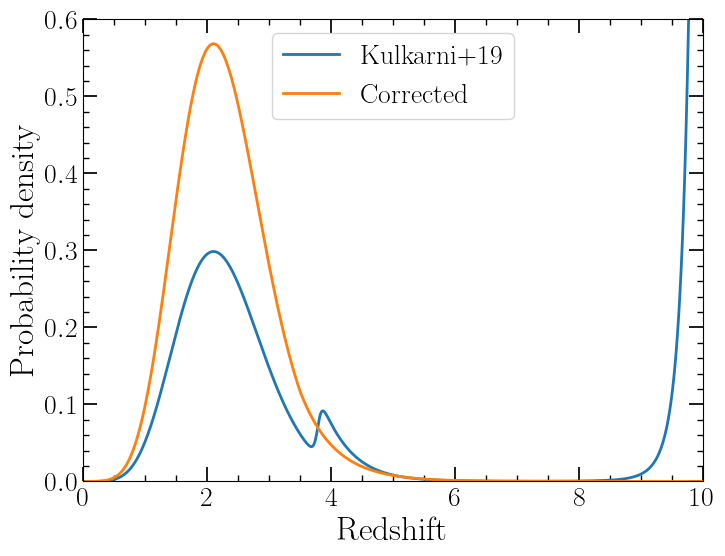

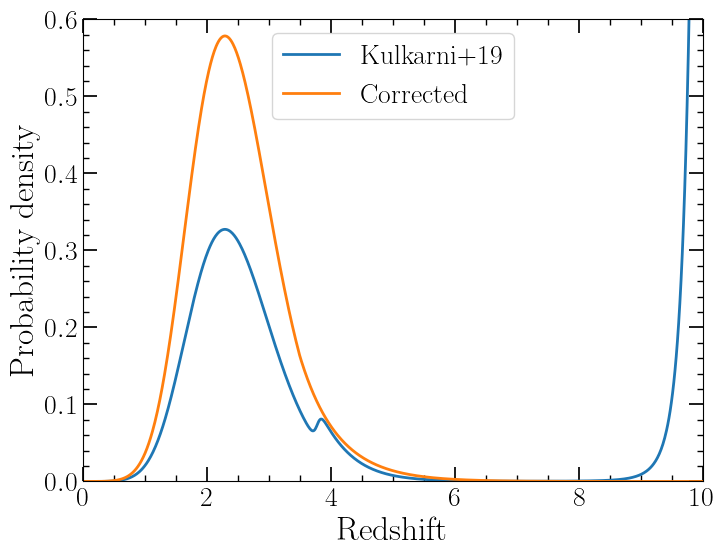

shenA...


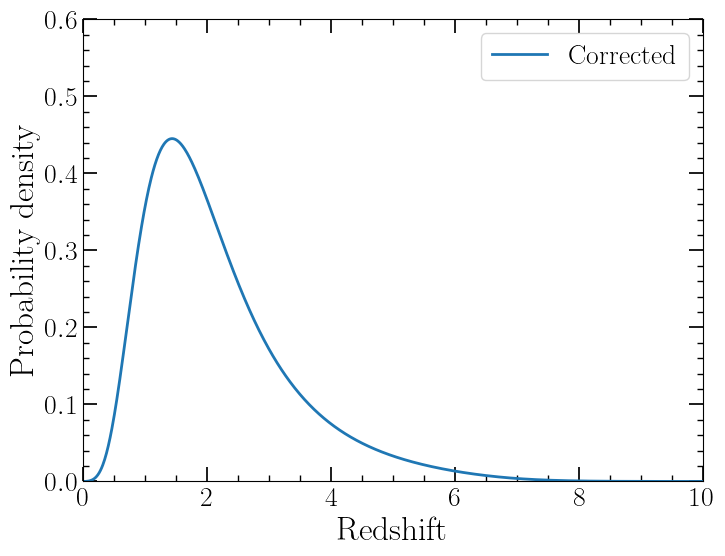

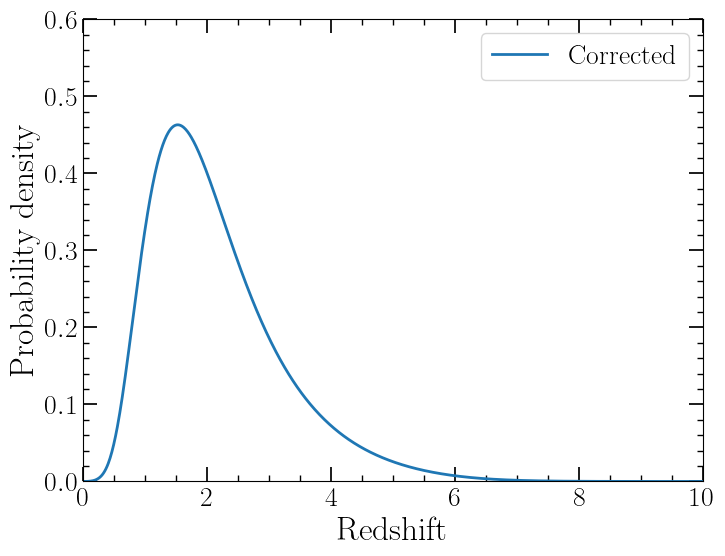

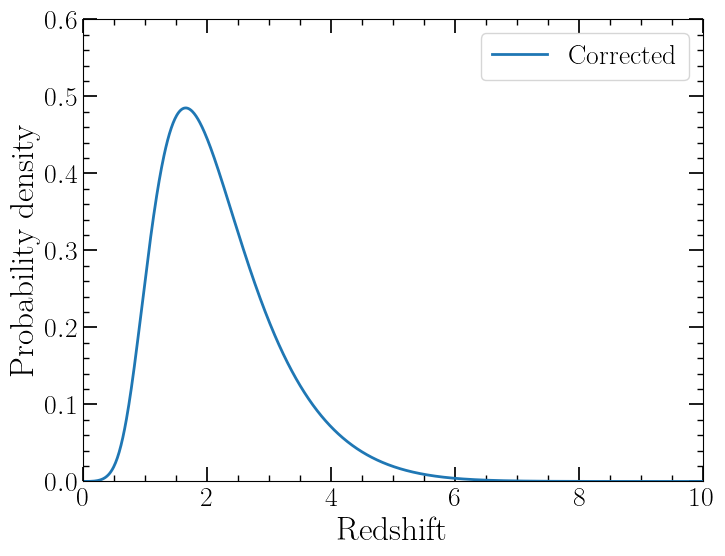

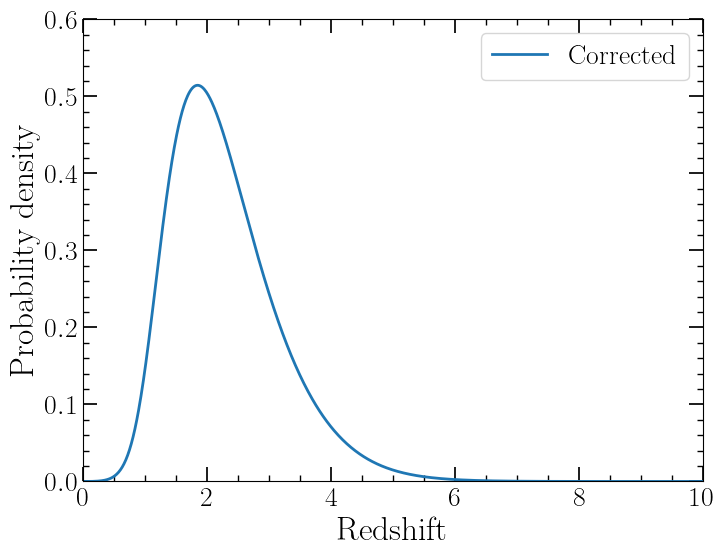

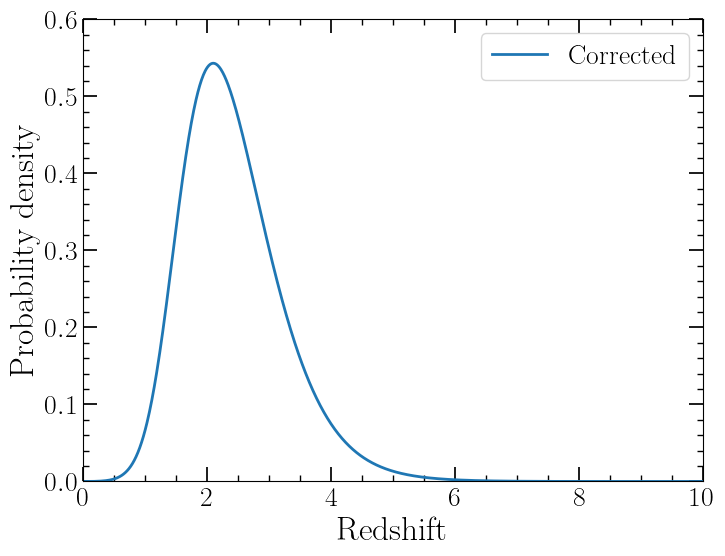

shenB...


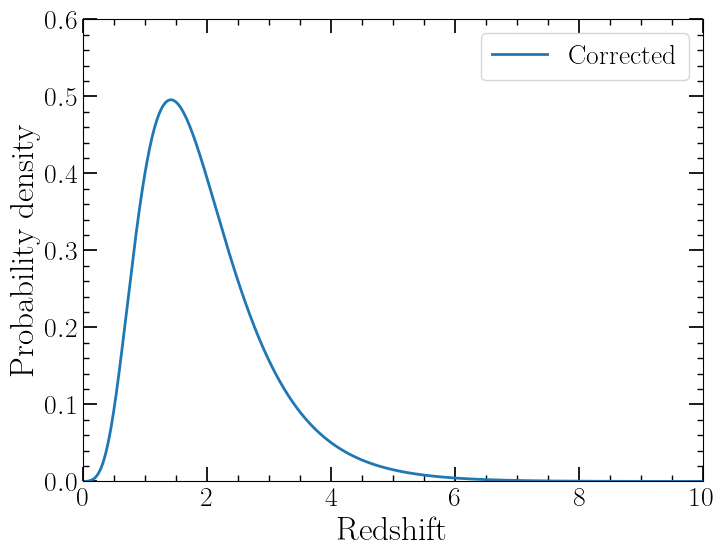

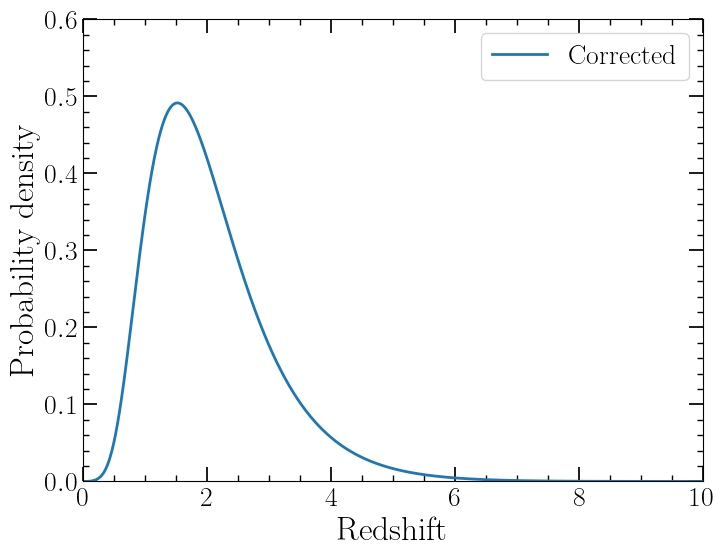

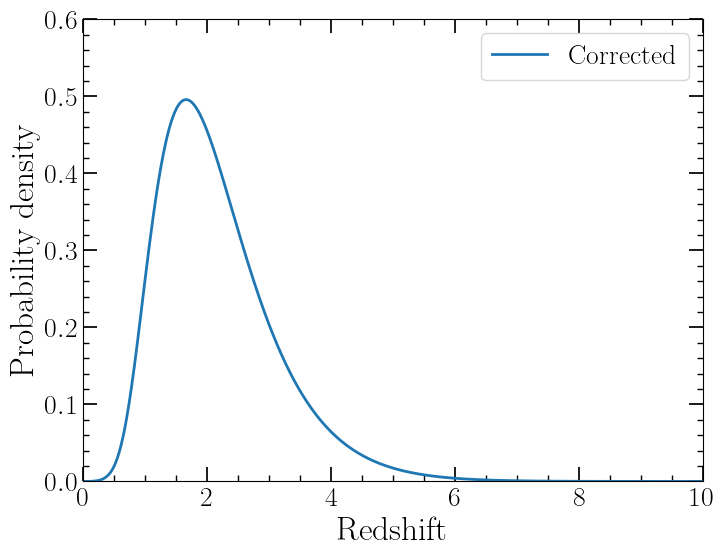

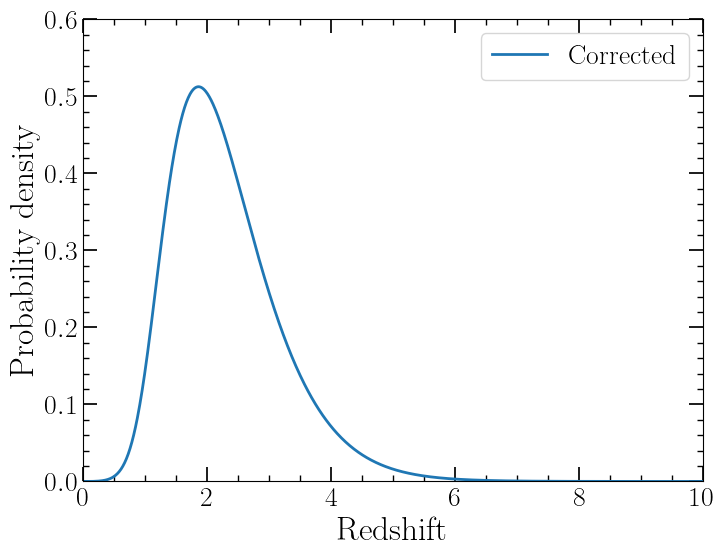

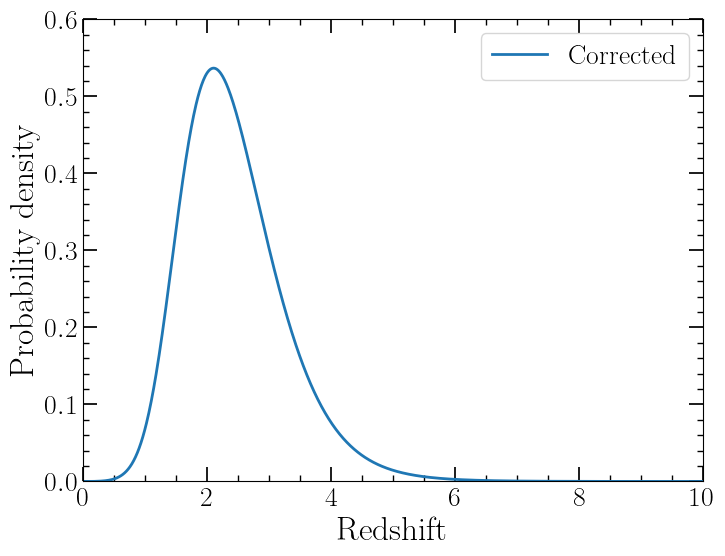

In [4]:
for qlf in ['kulkarni', 'shenA', 'shenB']:
    print(f'{qlf}...')
    for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):
        n_of_z = get_n_of_z(qlf=qlf, log10_Lbol_thresh=L_thresh)  # Step 1: Get number densities by integrating QLF over magnitude
        agn_redshift_pdf = numdens2pdf(n_of_z, REDSHIFT, cosmo=COSMO)  # Step 2: Get redshift PDFs by multiplying by dV/(dzdOmega) * 4pi * dz (i.e., multiply number density by dV)

        # Step 3: Remove peak from Kulkarni QLF (optional)
        if qlf == 'kulkarni':
            agn_redshift_pdf_wpeak = agn_redshift_pdf.copy()
            agn_redshift_pdf, param = remove_peak(agn_redshift_pdf_wpeak, REDSHIFT)

            plt.figure(figsize=(8,6))
            plt.plot(REDSHIFT, agn_redshift_pdf_wpeak, label='Kulkarni+19', linewidth=2)
            plt.plot(REDSHIFT, agn_redshift_pdf, label='Corrected', linewidth=2)
            plt.xlim(0, 10)
            plt.ylim(0, 0.6)
            plt.xlabel('Redshift')
            plt.ylabel('Probability density')
            plt.legend()
            # plt.grid()
            # plt.savefig('p26plots/kulkarni44p5_corrected.pdf', bbox_inches='tight')
            plt.show()

        else:
            plt.figure(figsize=(8,6))
            plt.plot(REDSHIFT, agn_redshift_pdf, label='Corrected', linewidth=2)
            plt.xlim(0, 10)
            plt.ylim(0, 0.6)
            plt.xlabel('Redshift')
            plt.ylabel('Probability density')
            plt.legend()
            # plt.grid()
            # plt.savefig('p26plots/kulkarni44p5_corrected.pdf', bbox_inches='tight')
            plt.show()


        # np.save(f'{AGN_DIST_DIR}/agn_redshift_pdf_{L_thresh}_{qlf}', np.array([redshift, agn_redshift_pdf]))


# Count the number of AGN up to a given redshift

Kulkarni: 23158
Corrected Kulkarni: 23159


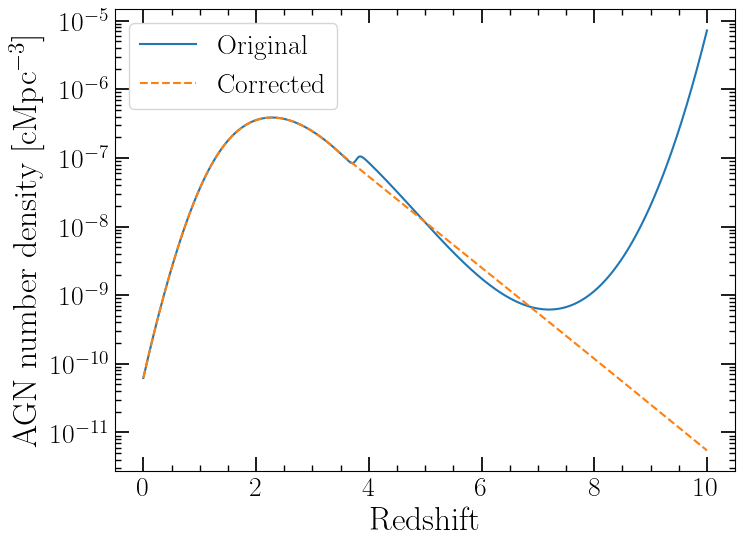

In [6]:
thresh = 46.5
AGN_ZPRIOR = f'{thresh}_kulkarni'
z_count_ax = np.linspace(0, 1.5, 1024+1)

# Load AGN distribution
filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
z, n = np.load(filename)
AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)

# Calculate old Kulkarni Nagn
n_of_z = get_n_of_z(qlf='kulkarni', log10_Lbol_thresh=thresh)
qlf_numdenses = n_of_z(REDSHIFT).flatten()
Nagn_total = romb(4 * np.pi * n_of_z(z_count_ax) * COSMO.differential_comoving_volume(z_count_ax), dx=np.diff(z_count_ax)[0])
print('Kulkarni:', int(Nagn_total))

# Calculate corrected Kulkarni Nagn
offset = qlf_numdenses[0] / pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT)(REDSHIFT)[0]
numdens_corrected_kulkarni = pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT, scaling=offset)
Nagn_total = romb(4 * np.pi * numdens_corrected_kulkarni(z_count_ax) * COSMO.differential_comoving_volume(z_count_ax), dx=np.diff(z_count_ax)[0])
print('Corrected Kulkarni:', int(Nagn_total))

# Plot old and new number densities
plt.figure(figsize=(8,6))
plt.plot(REDSHIFT, qlf_numdenses, label='Original')
plt.plot(REDSHIFT, numdens_corrected_kulkarni(REDSHIFT), linestyle='dashed', label='Corrected')
plt.semilogy()
plt.xlabel('Redshift')
plt.ylabel(r'AGN number density [$\mathrm{cMpc^{-3}}$]')
plt.legend()
# plt.savefig('./plots/corrected_kulkarni_46.5.pdf', bbox_inches='tight')
plt.show()


# Generate AGN posteriors

In [67]:
AGN_ZPRIOR = None
AGN_ZPRIOR_FUNCTION = None
AGN_COMDIST_MAX = COSMO.comoving_distance(AGN_ZMAX).value


def get_agn_zprior():
    """
    'positive_redshift', 'uniform_comoving_volume', '44.5_<QLF>', '45.0_<QLF>', '45.5_<QLF>', '46.0_<QLF>', '46.5_<QLF>'
    """

    if AGN_ZPRIOR == 'uniform_comoving_volume':
        return lambda z: uniform_comoving_prior(z)
    
    elif str(AGN_ZPRIOR)[:4] in LOG10_LBOL_THRESHES.astype(str):
        filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
        if VERBOSE:
            print(f'Loading AGN redshift distribution calculated from QLF from file: {filename}')
        z, n = np.load(filename)
        return interp1d(z, n, bounds_error=False, fill_value=0)
    
    elif AGN_ZPRIOR == 'positive_redshift':  # Equivalent to a uniform-in-redshift prior. Redundant since the Z_INTEGRAL_AX is >0, but this way we enforce a conscious decision on the prior.
        return lambda z: z_cut(-z, zcut=0)
    
    else:
        sys.exit(f'AGN redshift prior not recognized: {AGN_ZPRIOR}. \nExiting...')


def compute_agn_posteriors_chunk(start, end, all_agn_z, all_agn_z_err, n_norm=100):
    '''
    Compute a chunk of AGN posteriors. This computation is vectorized.
    AGN redshift posteriors are modelled as truncnorms on [0, inf) with a uniform-in-comoving-volume redshift prior.
    The posteriors are then evaluated on Z_INTEGRAL_AX, which is what is necessary for the crossmatch.
    '''
    z_chunk = all_agn_z[start:end]
    zerr_chunk = all_agn_z_err[start:end]
    mu = z_chunk[:, None]
    sigma = zerr_chunk[:, None]
    
    # Build per-AGN normalization axes
    t = np.linspace(0, 1, n_norm)[None, :]
    z_norm_ax = np.maximum(mu - 10*sigma, ZMIN) + t * (20 * sigma)
    
    # Get normalization of all posteriors --> evaluate on z_norm_ax
    posteriors_unnorm = truncnorm_pdf_inplace(z_norm_ax, mu, sigma, zmin=ZMIN)
    posteriors_unnorm *= z_cut(z_norm_ax, zcut=AGN_ZMAX)
    posteriors_unnorm *= AGN_ZPRIOR_FUNCTION(z_norm_ax)
    z_norms = np.trapezoid(posteriors_unnorm, z_norm_ax, axis=1)

    # Get normalized posteriors --> evaluate on Z_INTEGRAL_AX
    posteriors = truncnorm_pdf_inplace(Z_INTEGRAL_AX, mu, sigma, zmin=ZMIN)
    posteriors *= z_cut(Z_INTEGRAL_AX, zcut=AGN_ZMAX)
    posteriors *= AGN_ZPRIOR_FUNCTION(Z_INTEGRAL_AX)
    posteriors /= z_norms[:, None]
    return posteriors


def compute_and_save_posteriors_hdf5(filename, all_agn_z, all_agn_z_err, n_norm=100):
    '''
    For real data, we should only have to do this computation once and reuse the stored values.
    For mock, this is not useful, since we use different AGN catalogues each time.
    '''

    n_agn = len(all_agn_z)
    n_z = len(Z_INTEGRAL_AX)  # Only need to save the posterior evaluated at this axis
    chunk_size = int(1e6 / n_z)
    with h5py.File(filename, "w") as f:
        dset = f.create_dataset("agn_redshift_posteriors", shape=(n_agn, n_z), dtype=np.float64)

        if VERBOSE:
            iterchunks = tqdm( range(0, n_agn, chunk_size) )
        else:
            iterchunks = range(0, n_agn, chunk_size)

        for start in iterchunks:
            end = min(start + chunk_size, n_agn)
            posteriors = compute_agn_posteriors_chunk(start, end, all_agn_z, all_agn_z_err, n_norm)
            dset[start:end, :] = posteriors

    if VERBOSE:
        print(f"All AGN posteriors written to {filename}")
    
    return


def compute_and_save_posteriors_hdf5_lum_informed_prior(filename, all_agn_z, all_agn_z_err, all_agn_Lbol, n_norm=100):
    # n_agn = len(all_agn_z)
    # n_z = len(Z_INTEGRAL_AX)  # Only need to save the posterior evaluated at this axis
    # with h5py.File(filename, "w") as f:
    #     dset = f.create_dataset("agn_redshift_posteriors", shape=(n_agn, n_z), dtype=np.float64)
    agn_zprior_norm_ax = np.linspace(0, AGN_ZMAX, 1024+1)

    summed_posteriors = np.zeros_like(Z_INTEGRAL_AX)
    for i, (mu, sigma) in tqdm( enumerate(zip(all_agn_z, all_agn_z_err)), total=len(all_agn_z) ):
        mu, sigma = np.atleast_1d(mu), np.atleast_1d(sigma)

        t = np.linspace(0, 1, n_norm)
        z_norm_ax = np.maximum(mu - 10*sigma, ZMIN) + t * (20 * sigma)

        # Get luminosity-informed redshift prior from QLF
        n_of_z = lambda z: 10**log10_QLF_kulkarni(M=L2M(all_agn_Lbol[i]), z=z)
        prior_wpeak = lambda z: numdens2pdf(n_of_z=n_of_z, redshift=z)
        prior, _ = remove_peak(prior_wpeak(agn_zprior_norm_ax), agn_zprior_norm_ax)
        prior_norm = romb(prior, dx=np.diff(agn_zprior_norm_ax)[0])

        pi_agn = interp1d(x=agn_zprior_norm_ax, y=prior / prior_norm, kind='linear', bounds_error=False, fill_value=0)
        pi_at_normax = pi_agn(z_norm_ax)
        pi_at_intax = pi_agn(Z_INTEGRAL_AX)

        # Get normalization of all posteriors --> evaluate on z_norm_ax
        posteriors_unnorm = truncnorm_pdf_inplace(z_norm_ax, mu, sigma, zmin=ZMIN)
        posteriors_unnorm *= z_cut(z_norm_ax, zcut=AGN_ZMAX)
        posteriors_unnorm *= pi_at_normax
        z_norm = np.trapezoid(posteriors_unnorm, z_norm_ax)

        # Get normalized posteriors --> evaluate on Z_INTEGRAL_AX
        posteriors = truncnorm_pdf_inplace(Z_INTEGRAL_AX, mu, sigma, zmin=ZMIN)
        posteriors *= z_cut(Z_INTEGRAL_AX, zcut=AGN_ZMAX)
        posteriors *= pi_at_intax
        posteriors /= z_norm

        if np.sum(np.isnan(posteriors)) != 0:
            continue

        summed_posteriors += posteriors.flatten()
    
    return summed_posteriors



In [ ]:
for qlf in ['kulkarni']:  # 'shenA', 'shenB', 
    for thresh in [46.5]:#LOG10_LBOL_THRESHES:

        df = pd.read_csv(QUAIA_PATH)
        cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "loglbol_corr"]
        data = df[cols]
        b              = data["b"].to_numpy()
        loglbol_corr   = data["loglbol_corr"].to_numpy()
        outside_galactic_plane = np.logical_or((b > 10), (b < -10))
        above_lbol_thresh = loglbol_corr >= float(thresh)

        agn_redshift       = data["redshift_quaia"].to_numpy()[outside_galactic_plane & above_lbol_thresh]
        agn_redshift_err   = data["redshift_quaia_err"].to_numpy()[outside_galactic_plane & above_lbol_thresh]

        filename = f'./quaia_testing_{thresh}_{qlf}.hdf5'

        AGN_ZPRIOR = f'{thresh}_{qlf}'
        AGN_ZPRIOR_FUNCTION = get_agn_zprior()

        # SoP_lum_informed = compute_and_save_posteriors_hdf5_lum_informed_prior(filename=None, all_agn_z=agn_redshift, all_agn_z_err=agn_redshift_err, all_agn_Lbol=loglbol_corr, n_norm=128+1)

        # compute_and_save_posteriors_hdf5(filename, agn_redshift, agn_redshift_err)


Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.5_kulkarni.npy


100%|██████████| 20236/20236 [02:09<00:00, 156.30it/s]


Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_44.5_kulkarni.npy
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_45.0_kulkarni.npy
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_45.5_kulkarni.npy
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.0_kulkarni.npy
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.5_kulkarni.npy


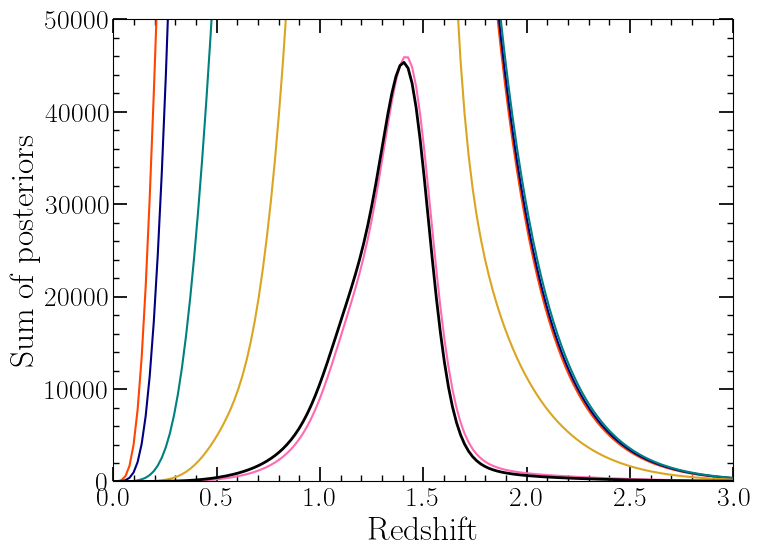

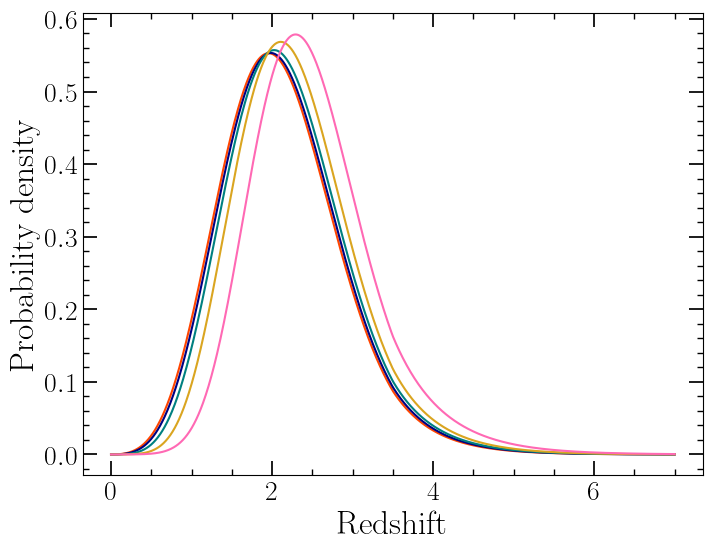

In [77]:
def get_label_linestyle(qlf):
    if qlf == 'shenA':
        linestyle = 'dotted'
        label = 'Shen+2020 A'
    elif qlf == 'shenB':
        linestyle = 'dashed'
        label = 'Shen+2020 B'
    elif qlf == 'kulkarni':
        linestyle = 'solid'
        label = 'Kulkarni+2019'
    else:
        sys.exit(f'Do not recognize QLF: {qlf}')
    return label, linestyle

def get_SoP(L_threshes, QLF, dir='./quaia_testing'):
    '''
    Get sums of posteriors for luminosity thresholds and specified QLF
    '''

    SoPs = []
    for L_thresh in L_threshes:
        filename = f'{dir}_{L_thresh}_{QLF}.hdf5'
        with h5py.File(filename, "r") as f:
            agn_posterior_dset = f["agn_redshift_posteriors"][()]
        SoPs.append(np.sum(agn_posterior_dset, axis=0))
    return SoPs


fig1, ax1 = plt.subplots(figsize=(8,6))
fig2, ax2 = plt.subplots(figsize=(8,6))

for qlf in ['kulkarni']:  # 'shenA', 'shenB', 

    label, linestyle = get_label_linestyle(qlf)

    SoP44_5, SoP45_0, SoP45_5, SoP46_0, SoP46_5 = get_SoP(LOG10_LBOL_THRESHES, qlf)
    
    for i, SoP in enumerate([SoP44_5, SoP45_0, SoP45_5, SoP46_0, SoP46_5]):
        ax1.plot(Z_INTEGRAL_AX, SoP, color=COLORS[i], linestyle=linestyle)
    
    ax1.plot(Z_INTEGRAL_AX, SoP_lum_informed, color='black', linestyle=linestyle, linewidth=2)
    ax1.set_ylim(0, 50000)

    for j, thresh in enumerate(LOG10_LBOL_THRESHES):
        AGN_ZPRIOR = f'{thresh}_{qlf}'
        AGN_ZPRIOR_FUNCTION = get_agn_zprior()
        ax2.plot(np.linspace(1e-4, 7, 1000), AGN_ZPRIOR_FUNCTION(np.linspace(1e-4, 7, 1000)), color=COLORS[j], linestyle=linestyle)

ax1.set_xlim(0, 3)
ax1.set_xlabel('Redshift')
ax2.set_xlabel('Redshift')
ax1.set_ylabel('Sum of posteriors')
ax2.set_ylabel('Probability density')
# ax1.semilogy()
plt.show()


# Plot results

In [9]:
def obs_numdens_of_z(z, sum_of_posteriors):
    observed_sky_fraction = 1 - np.sin(np.deg2rad(10))
    numdens = pdf2numdens(sum_of_posteriors, Z_INTEGRAL_AX, scaling=1 / observed_sky_fraction)
    return numdens(z)

def redshift_completeness(z, completeness_zedges, completeness_zvals):
    bin_idx = np.digitize(z, completeness_zedges) - 1
    bin_idx[bin_idx == len(completeness_zvals)] = len(completeness_zvals) - 1
    return completeness_zvals[bin_idx.astype(np.int32)]


In [84]:
THRESHOLD_MAP = {"46.5": 0, "46.0": 1, "45.5": 2, "45.0": 3, "44.5": 4}
V25_zedges = np.array([0.0000, 0.1875, 0.3750, 0.5625, 0.7500, 0.9375, 1.1250, 1.3125, AGN_ZCUT, AGN_ZMAX])
QUAIA_C_VALS = np.array([
                    [0.000, 0.000, 0.229, 0.945, 0.718],
                    [1.000, 1.000, 1.000, 1.000, 0.781],
                    [1.000, 1.000, 1.000, 1.000, 0.408],
                    [1.000, 0.891, 1.000, 0.681, 0.211],
                    [1.000, 1.000, 0.994, 0.429, 0.138],
                    [1.000, 1.000, 0.837, 0.258, 0.085],
                    [0.927, 0.940, 0.576, 0.179, 0.060],
                    [1.000, 1.000, 0.482, 0.155, 0.053],
                    [0., 0., 0., 0., 0.]])


def make_qlf_plots(axs, qlf, L_thresh, redshift, color):

    try:
        ax1, ax2, ax3 = axs
    except:
        ax1, ax3 = axs

    # Plot number densities
    n_of_z = get_n_of_z(qlf=qlf, log10_Lbol_thresh=L_thresh)
    qlf_numdenses = n_of_z(redshift).flatten()

    sum_of_posteriors = get_SoP(np.atleast_1d(L_thresh), qlf)[0]
    obs_numdenses = obs_numdens_of_z(redshift, sum_of_posteriors)

    AGN_ZPRIOR = f'{L_thresh}_{qlf}'
    filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
    z, n = np.load(filename)
    AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)
    
    offset = qlf_numdenses[0] / pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT)(redshift)[0]
    numdens_corrected_kulkarni = pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT, scaling=offset)

    ax1.plot(redshift, qlf_numdenses, color=color, linewidth=2, linestyle='dotted')
    ax1.plot(redshift, numdens_corrected_kulkarni(redshift), color=color, linewidth=2, linestyle='dashed')
    ax1.plot(redshift, obs_numdenses, color=color, linewidth=2, linestyle='solid')

    # Plot PDFs
    agn_redshift_pdf = numdens2pdf(n_of_z, redshift, cosmo=COSMO) 
    if qlf == 'kulkarni':
        agn_redshift_pdf_wpeak = agn_redshift_pdf.copy()
        agn_redshift_pdf, _ = remove_peak(agn_redshift_pdf_wpeak, REDSHIFT)
    try:
        ax2.plot(redshift, agn_redshift_pdf, color=color, linewidth=2, linestyle=linestyle)
    except:
        print('Not plotting PDFs')

    # Plot completenesses
    fc_of_z = obs_numdenses / qlf_numdenses
    ax3.plot(redshift, fc_of_z, color=color, linewidth=2, linestyle='solid', label=label)

    if L_thresh == 46.5:
        ax3.plot(Z_INTEGRAL_AX, obs_numdens_of_z(Z_INTEGRAL_AX, SoP_lum_informed) / n_of_z(Z_INTEGRAL_AX).flatten(), color='black')

    # np.save(f'{AGN_DIST_DIR}/completeness_{L_thresh}_{QLF}', np.array([redshift_bin_centers, fc_of_z]))

    return


Not plotting PDFs
Not plotting PDFs
Not plotting PDFs
Not plotting PDFs
Not plotting PDFs


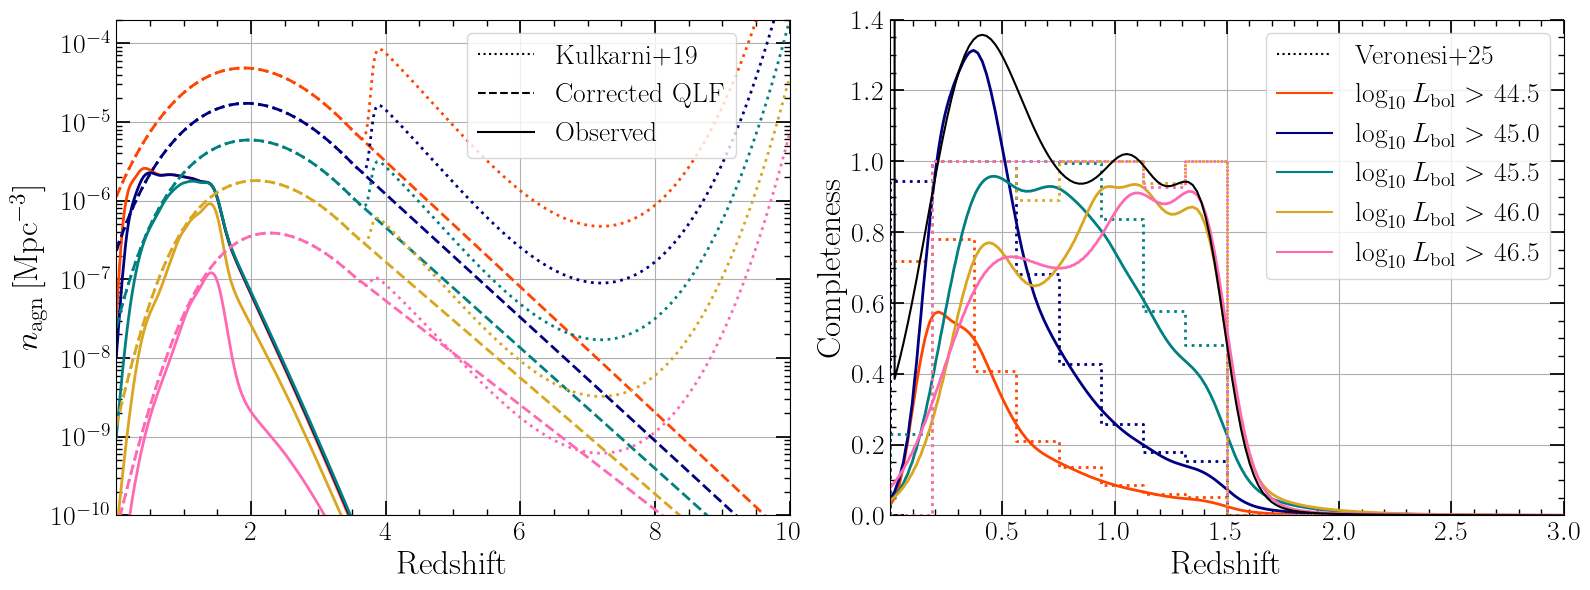

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):
    ax1, ax3 = ax[0], ax[1]
    ax3.step(V25_zedges, np.append( 0, np.array(QUAIA_C_VALS[:, THRESHOLD_MAP[str(L_thresh)]]) ), linewidth=2, label='Veronesi+25', color=COLORS[i], linestyle='dotted')
    make_qlf_plots([ax1, ax3], 'kulkarni', L_thresh, REDSHIFT, color=COLORS[i])

ax1.semilogy()
ax1.set_xlim(ZMIN, ZMAX)
ax1.set_ylim(1e-10, 2e-4)  # ax1.set_ylim(1e-10, 2e-4)
ax1.set_xlabel('Redshift')
ax1.set_ylabel(r'$n_{\rm agn} \, [\mathrm{Mpc^{-3}}]$')
ax1.grid()
ax3.grid()
ax3.set_xlim(ZMIN, 3)
ax3.set_ylim(0, 1.4)
ax3.set_ylabel(r'Completeness')
ax3.set_xlabel('Redshift')
custom_handles = [Line2D([], [], color='black', linestyle='dotted', label='Kulkarni+19'),
                  Line2D([], [], color='black', linestyle='dashed', label='Corrected QLF'),
                  Line2D([], [], color='black', linestyle='solid', label='Observed')]
ax1.legend(handles=custom_handles, bbox_to_anchor=(0.5, 1), loc='upper left')
custom_handles = [Line2D([], [], color='black', linestyle='dotted', label='Veronesi+25')]
for i, thresh in enumerate(LOG10_LBOL_THRESHES):
    custom_handles.append(Line2D([], [], color=COLORS[i], linestyle='solid', label=r'$\log_{10} L_{\rm bol} >$ ' + str(thresh)))
ax3.legend(handles=custom_handles)
plt.tight_layout()
# plt.savefig('p26plots/completeness.pdf', bbox_inches='tight')
plt.show()


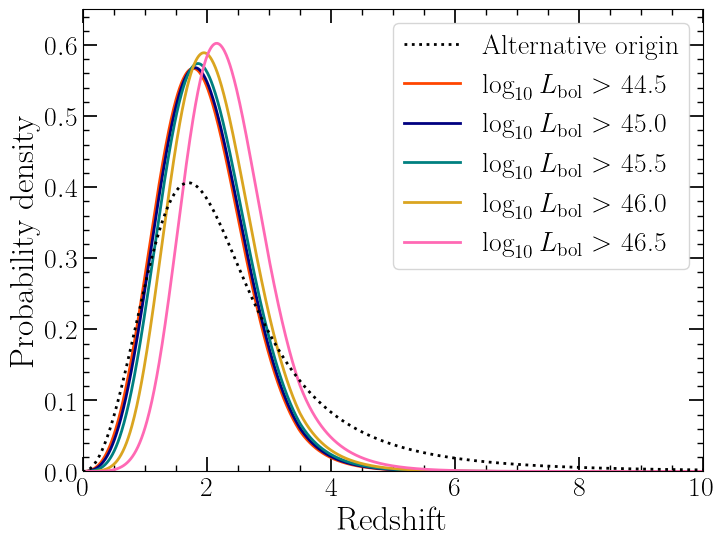

In [12]:
def make_merger_rate_plots(ax, qlf, L_thresh, redshift, color, label, linestyle, time_dilation=False):
    
    AGN_ZPRIOR = f'{L_thresh}_{qlf}'
    filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
    z, n = np.load(filename)
    AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)
    agn_redshift_pdf = AGN_ZPRIOR_FUNCTION(redshift)

    if time_dilation:
        observed_rate_evolution = agn_redshift_pdf * time_dilation_correction(redshift) / romb(agn_redshift_pdf * time_dilation_correction(redshift), dx=np.diff(redshift)[0])
    else:
        observed_rate_evolution = agn_redshift_pdf / romb(agn_redshift_pdf, dx=np.diff(redshift)[0])

    ax.plot(redshift, observed_rate_evolution, color=color, linewidth=2, linestyle=linestyle, label=label)

    return


### PLOT ###
fig, ax = plt.subplots(figsize=(8,6))
alt_pop = uniform_comoving_prior(REDSHIFT) * time_dilation_correction(REDSHIFT) * merger_rate_madau_dickinson(REDSHIFT)
alt_pop_norm = alt_pop / romb(alt_pop, dx=np.diff(REDSHIFT)[0])
ax.plot(REDSHIFT, alt_pop_norm, label=r'Alternative origin', color='black', linestyle='dotted', linewidth=2, zorder=3)
for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):  
    make_merger_rate_plots(ax, 'kulkarni', L_thresh, REDSHIFT, color=COLORS[i], linestyle='solid', time_dilation=True,label = r'$\log_{10} L_{\rm bol} >$ ' + str(L_thresh))
ax.set_xlim(ZMIN, ZMAX)
ax.set_xlabel('Redshift')
ax.set_ylabel('Probability density')
ax.legend(fontsize=20)
ax.set_ylim(0, 0.65)
ax.set_xlim(0, ZMAX)
# plt.savefig('p26plots/all_populations.pdf', bbox_inches='tight')
plt.show()


# Investigate magnitude and effect of bolometric luminosity uncertainties on the completeness

179916


100%|██████████| 1000/1000 [00:08<00:00, 117.16it/s]


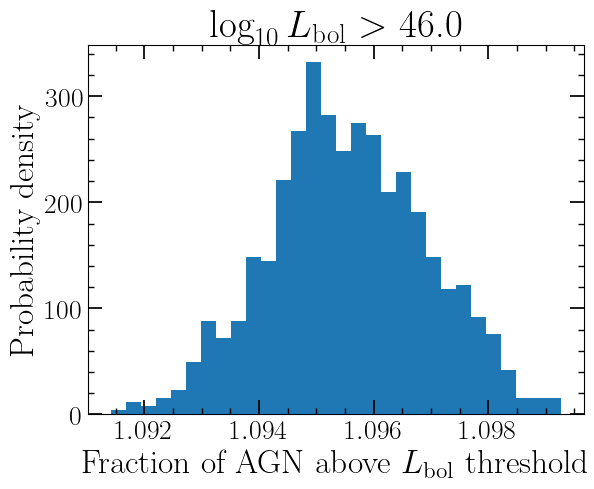

In [13]:
err = 0.2
N = int(1e3)
l = 46.0

for QLF in ['kulkarni']:  # 'shenA', 'shenB', 

    for thresh in [l]:

        df = pd.read_csv(QUAIA_PATH)
        cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "loglbol_corr"]
        data = df[cols]
        b              = data["b"].to_numpy()
        loglbol_corr   = data["loglbol_corr"].to_numpy()

        baseline = np.sum(loglbol_corr >= float(thresh))
        print(baseline)
        
        N_above_thresh = np.zeros(N)
        for i in tqdm(range(N)):
            loglbol_corr_meas = np.random.normal(loglbol_corr, scale=err)
            # plt.figure()
            # plt.hist(loglbol_corr_meas, bins=30)
            # plt.vlines(thresh, 0, 2e5, color='black')
            # plt.show()
            
            N_above_thresh[i] = np.sum(loglbol_corr_meas >= float(thresh))
            # print(N_above_thresh[i], N_above_thresh[i] / baseline)
            # sys.exit(1)

plt.figure()
plt.hist(N_above_thresh / baseline, bins=30, density=True)
plt.xlabel(r'Fraction of AGN above $L_{\rm bol}$ threshold')
plt.ylabel('Probability density')
plt.title(r'$\log_{10} L_{\rm bol} >$ ' + str(l))
plt.show()
